# 1.5 - Manual clustering (tune, eyeball & merge)

Self-contained tuning playground. Everything is in this notebook: it **fits
k-means here**, draws every cluster, and lets you merge them by hand. No
silhouette / elbow / scoring - you decide from the pictures.

**Tune** the two knobs at the top (`K` and `DAY_WEIGHTS`), then re-run top to
bottom -> the clusters update. Retroflection lives at day 30-50, the destination
at day 180, so a **U-shaped** weighting (early high, middle low, late high)
captures both.

1. Fit k-means (weighted, standardized - same space as the pipeline).
2. Grid: orange = centroid track, grey = full member trajectories.
3. Hand-assign each cluster a **group letter** in `ASSIGN` (same letter = merged).
4. Last cell prints `GROUP_MAP` / `GROUP_NAMES` to paste into `config.py`.

In [14]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # project root: config.py, pipeline.py
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
import config as C
import pipeline as P

# --- TUNE ME -----------------------------------------------------------------
K = 50       # over-resolve: minority pathways (retroflection) need enough clusters

# Per-day weights, tuned HERE without touching config.py (nb02/03 still use config).
# Set DAY_WEIGHTS = None to fall back to config.DAY_WEIGHTS.
# U-shape below: emphasise retroflection (day 30-50) AND the endpoint (day 180).
DAY_WEIGHTS = {30: 0.5, 50: 1.5, 100: 1.0, 150: 1.5, 180: 2.0}
# -----------------------------------------------------------------------------

_wd = DAY_WEIGHTS if DAY_WEIGHTS is not None else C.DAY_WEIGHTS
W   = np.array([np.sqrt(_wd[d]) for d in C.DAYS for _ in range(2)])   # sqrt(w) per column
print("days:", C.DAYS, "| K:", K, "| weights:", _wd)

days: [30, 50, 100, 150, 180] | K: 50 | weights: {30: 0.5, 50: 1.5, 100: 1.0, 150: 1.5, 180: 2.0}


## Fit k-means (here, so tuning re-clusters)
Standardize each day to mean 0 / std 1, apply the per-day weights `W`, then fit.
Change `K` or `DAY_WEIGHTS` above and re-run this cell to get new clusters.

In [15]:
features = pd.read_parquet(C.FEATURES_FILE)
complete = features[features.status == "complete"]
sub = complete.sample(n=min(C.N_SUB, len(complete)),
                      random_state=C.RANDOM_STATE).reset_index(drop=True)

X_raw  = P.build_feature_matrix(sub)                      # raw degrees
scaler = StandardScaler().fit(X_raw)
X_sub  = scaler.transform(X_raw) * W                      # standardized + weighted

km = MiniBatchKMeans(n_clusters=K, random_state=C.RANDOM_STATE,
                     batch_size=10000, n_init=10, max_iter=300)
labels = km.fit_predict(X_sub)
sizes  = np.bincount(labels, minlength=K)

# centroids back to real degrees: [lat_d0, lon_d0, lat_d1, lon_d1, ...]
cent_deg = P.centroids_to_degrees(km.cluster_centers_ / W, scaler)
print(f"fit k={K} on {len(sub):,} trajectories | cluster sizes {sizes.min()}..{sizes.max()}")

fit k=50 on 500,000 trajectories | cluster sizes 1406..71799


## Cheap coastline
Coarsest Natural Earth coastline (110 m) loaded **once** as plain (lon, lat)
segments and drawn as thin grey lines on ordinary axes -> a map backdrop without
a cartopy GeoAxes per panel.

In [16]:
import cartopy.feature as cfeature
lon = (C.DOMAIN["lon_min"], C.DOMAIN["lon_max"])
lat = (C.DOMAIN["lat_min"], C.DOMAIN["lat_max"])

_coast = []
for geom in cfeature.COASTLINE.with_scale("110m").geometries():
    for line in getattr(geom, "geoms", [geom]):
        _coast.append((np.asarray(line.xy[0]), np.asarray(line.xy[1])))

def draw_coast(ax):
    for x, y in _coast:
        ax.plot(x, y, "-", color="0.75", lw=.4, zorder=0)
    ax.set_xlim(*lon); ax.set_ylim(*lat)
print("coastline segments:", len(_coast))

coastline segments: 134


## All clusters on one map
Every centroid track together (no particle trajectories) - one overview of how
the `K` clusters spread. Number = cluster id at its day-{last} endpoint.

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
draw_coast(ax)
allcmap = plt.get_cmap("tab20", K)
for c in range(K):
    lo, la = cent_deg[c, 1::2], cent_deg[c, 0::2]      # centroid track (degrees)
    ax.plot(lo, la, "-", color=allcmap(c), lw=1.2, alpha=.8, zorder=2)
    # ax.plot(lo[-1], la[-1], "o", color=allcmap(c), mec="k", ms=5, zorder=3)
    ax.text(lo[-1], la[-1], str(c), fontsize=7, ha="center", va="center", zorder=4)
ax.set_title(f"All {K} centroid tracks (day {C.DAYS[0]} -> {C.DAYS[-1]})")
fig.tight_layout(); plt.show()


## Stream a few FULL member trajectories per cluster
Pick `MEMBERS_PER_PANEL` trajectory_ids per cluster and read their whole
`lon`/`lat` path from Zarr (open each store once). Bounded I/O:
`K x MEMBERS_PER_PANEL` paths.

In [18]:
MEMBERS_PER_PANEL = 12
N_IO_THREADS = int(os.environ.get("SLURM_CPUS_PER_TASK", 16))
stores = C.list_stores()

memdf = pd.DataFrame({"trajectory_id": sub.trajectory_id.to_numpy(), "lab": labels})
pick = (memdf.groupby("lab", group_keys=False)
              .apply(lambda d: d.sample(min(MEMBERS_PER_PANEL, len(d)),
                                        random_state=C.RANDOM_STATE)))
pick["store_index"] = pick.trajectory_id // C.TRAJ_PER_STORE
pick["local"]       = pick.trajectory_id %  C.TRAJ_PER_STORE

def _read_paths(si, grp):
    ds  = xr.open_zarr(stores[si])
    loc = grp.local.to_numpy()
    return grp.trajectory_id.to_numpy(), ds.lon.values[loc], ds.lat.values[loc]

res = Parallel(n_jobs=N_IO_THREADS, backend="threading")(
    delayed(_read_paths)(si, grp) for si, grp in pick.groupby("store_index"))

paths = {}                                        # trajectory_id -> (lon[obs], lat[obs])
for tids, plon, plat in res:
    for j, tid in enumerate(tids):
        paths[int(tid)] = (plon[j], plat[j])
members = {c: pick.loc[pick.lab == c, "trajectory_id"].to_numpy() for c in range(K)}
print(f"streamed {len(paths):,} full trajectories from {pick.store_index.nunique()} stores")

/tmp/ipykernel_1380870/2995321380.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: d.sample(min(MEMBERS_PER_PANEL, len(d)),


streamed 600 full trajectories from 504 stores


## The grid - one panel per cluster
Grey coastline + grey full member paths + orange centroid track (first -> last
day in `C.DAYS`). This is the picture you group from.

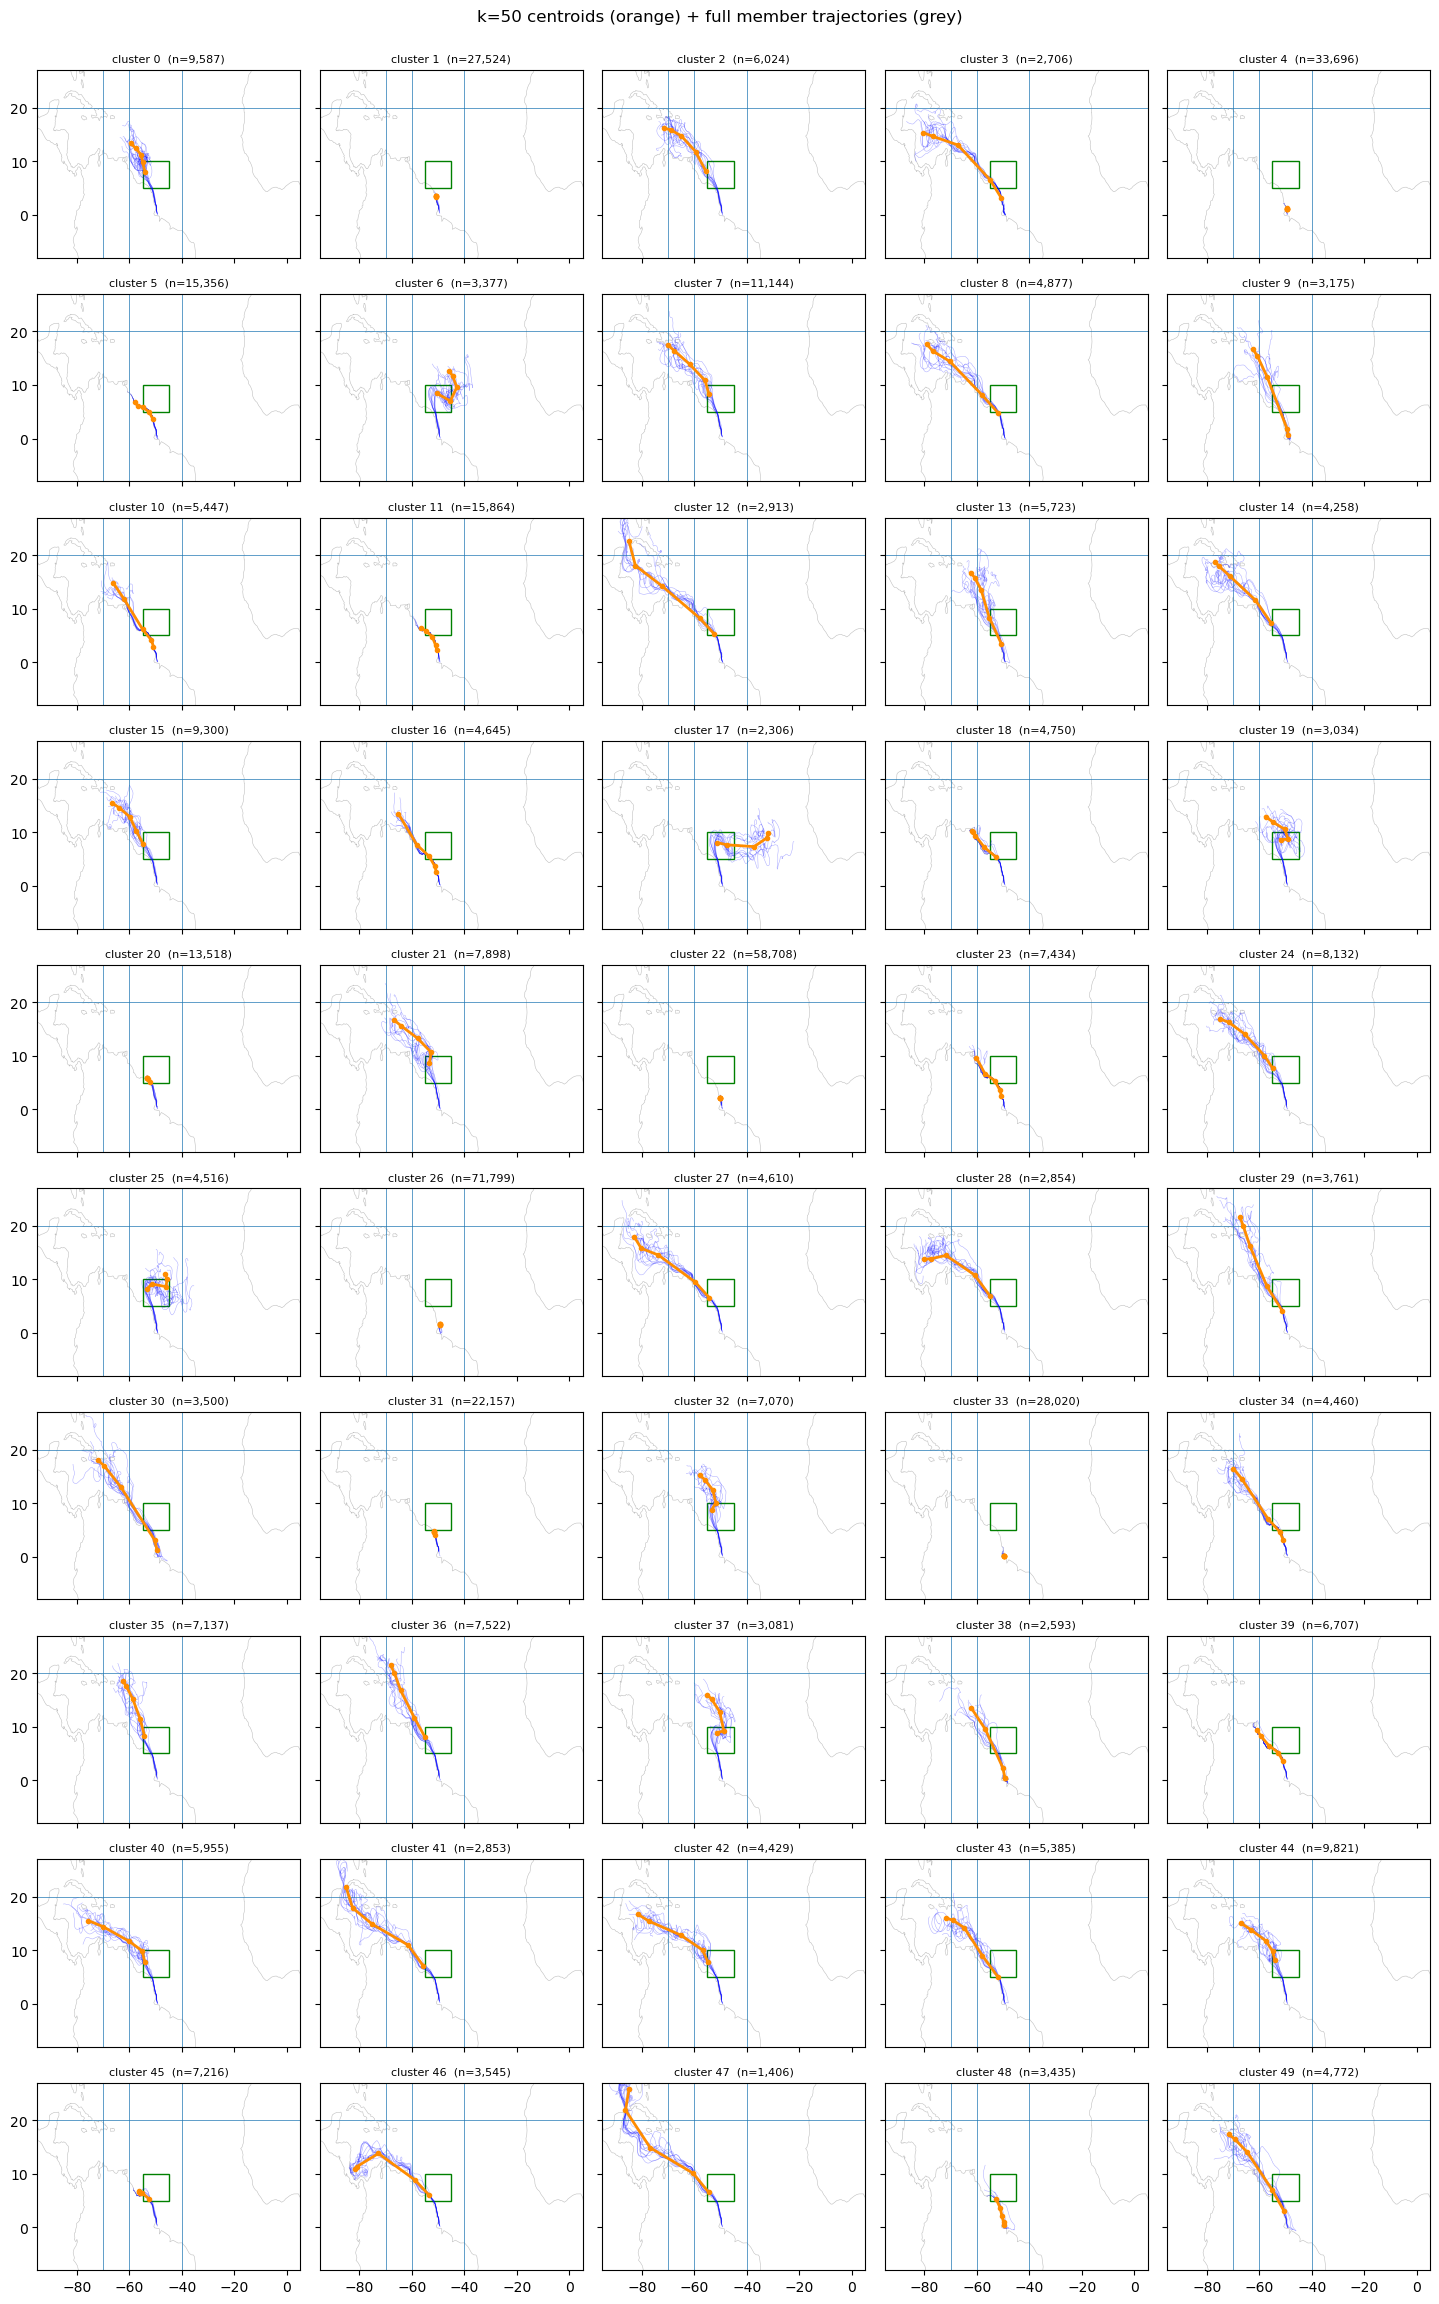

In [19]:
import matplotlib.patches as mpatches

NCOL = 5

def draw_cluster(ax, c):
    draw_coast(ax)
    for tid in members[c]:
        lo, la = paths[int(tid)]
        m = ~(np.isnan(lo) | np.isnan(la))             # drop the NaN tail (early-ended)
        ax.plot(lo[m], la[m], "-", color="blue", lw=.4, alpha=.3)
    clo, cla = cent_deg[c, 1::2], cent_deg[c, 0::2]    # centroid
    ax.plot(clo, cla, ".-", color="darkorange", lw=2, zorder=3)

nrow = int(np.ceil(K / NCOL))
fig, axes = plt.subplots(nrow, NCOL, figsize=(2.9 * NCOL, 2.3 * nrow),
                         squeeze=False, sharex=True, sharey=True)
for c in range(K):
    ax = axes[c // NCOL][c % NCOL]
    draw_cluster(ax, c)
    ax.set_title(f"cluster {c}  (n={sizes[c]:,})", fontsize=8)

    ax.axvline(-70,linewidth=0.5)
    ax.axvline(-60,linewidth=0.5)
    ax.axhline(20,linewidth=0.5)
    ax.axvline(-40,linewidth=0.5)
    rect= mpatches.Rectangle(
    xy=(-55, 5),
    width=10,
    height=5,
    linewidth=1,
    edgecolor='green',
    facecolor='none'
    )
    ax.add_patch(rect)
    
for j in range(K, nrow * NCOL):
    axes[j // NCOL][j % NCOL].axis("off")
fig.suptitle(f"k={K} centroids (orange) + full member trajectories (grey)", y=1.0)
fig.tight_layout()

# fig.savefig(f"cluster_K{K}_W_{_wd}.pdf", dpi=130, bbox_inches="tight")
plt.show()

## Assign each cluster a group letter
`ASSIGN[cluster] = "letter"`. Same letter => merged. Start all-separate and merge
by reading the grid above (e.g. collect the retroflection clusters into one letter).

In [20]:
# Grouping transferred from the PRE-rerun fit: each new centroid inherits the
# letter of its nearest old centroid (data/kmeans_models/manual_1.5_k50/), same
# distance metric as cell 16. Median match 2.6 deg, max 7.1 deg.
# Full table with distances + runner-up: data/grouping_transfer_old_to_new.csv
#
# THIS IS A DRAFT - check these against the grid above before trusting it:
#   near-tie with a different letter: [2, 4, 13, 14, 26, 28, 30, 40, 43, 48, 49]
#     worst margins: 49 (A2/B2 by 0.2), 40 (A2/B2 by 0.3), 43 (B2/A2 by 0.3)
#   weakest matches (top 10% distance): [9, 14, 30, 40, 42]
#   F collapsed 3 clusters -> 1 (new 17, n=2,306): old 8 and old 45 both map
#     onto it, old 14 landed 8.5 deg away inside new 25 (C).
ASSIGN = {
   0:"CB",   1:"E1",   2:"A2",   3:"A2",   4:"E",    5:"S",    6:"C",    7:"B2",   8:"A2",   9:"B3",
   10:"BS",  11:"S",   12:"A1",  13:"B2",  14:"A12", 15:"B2",  16:"BS",  17:"F",   18:"S",   19:"C",
   20:"E0",  21:"B2",  22:"E2",  23:"S",   24:"A2",  25:"C",   26:"E",   27:"A2",  28:"A2",  29:"B1",
   30:"A2",  31:"E1",  32:"C",   33:"E",   34:"BS",  35:"CB",  36:"B1",  37:"C",   38:"BS",  39:"S",
   40:"A2",  41:"A1",  42:"A2",  43:"B2",  44:"B2",  45:"S",   46:"A3",  47:"A1",  48:"S",   49:"A2",
}

# --- previous grouping, keyed to the OLD cluster ids (kept for reference) ----
# ASSIGN = {
#     0:"A2",  1:"E1",  2:"B1",  3:"BS",  4:"E2",  5:"A2",  6:"C",   7:"B2",  8:"F",   9:"S",
#    10:"B2", 11:"B3", 12:"C",  13:"B2", 14:"F",  15:"S",  16:"A1", 17:"BS", 18:"E",  19:"S",
#    20:"A2", 21:"E0", 22:"A2", 23:"B2", 24:"B3", 25:"S",  26:"CB", 27:"E2", 28:"B2", 29:"B2",
#    30:"C",  31:"A1", 32:"E",  33:"A3", 34:"B2", 35:"A12",36:"A2", 37:"S",  38:"B2", 39:"A2",
#    40:"B1", 41:"S",  42:"A2", 43:"BS", 44:"C",  45:"F",  46:"B2", 47:"CB", 48:"B1", 49:"E1",
# }


## Preview the merged groups
One panel per letter, overlaying every centroid you assigned to it. Lines
disagree -> split; two panels look identical -> merge.

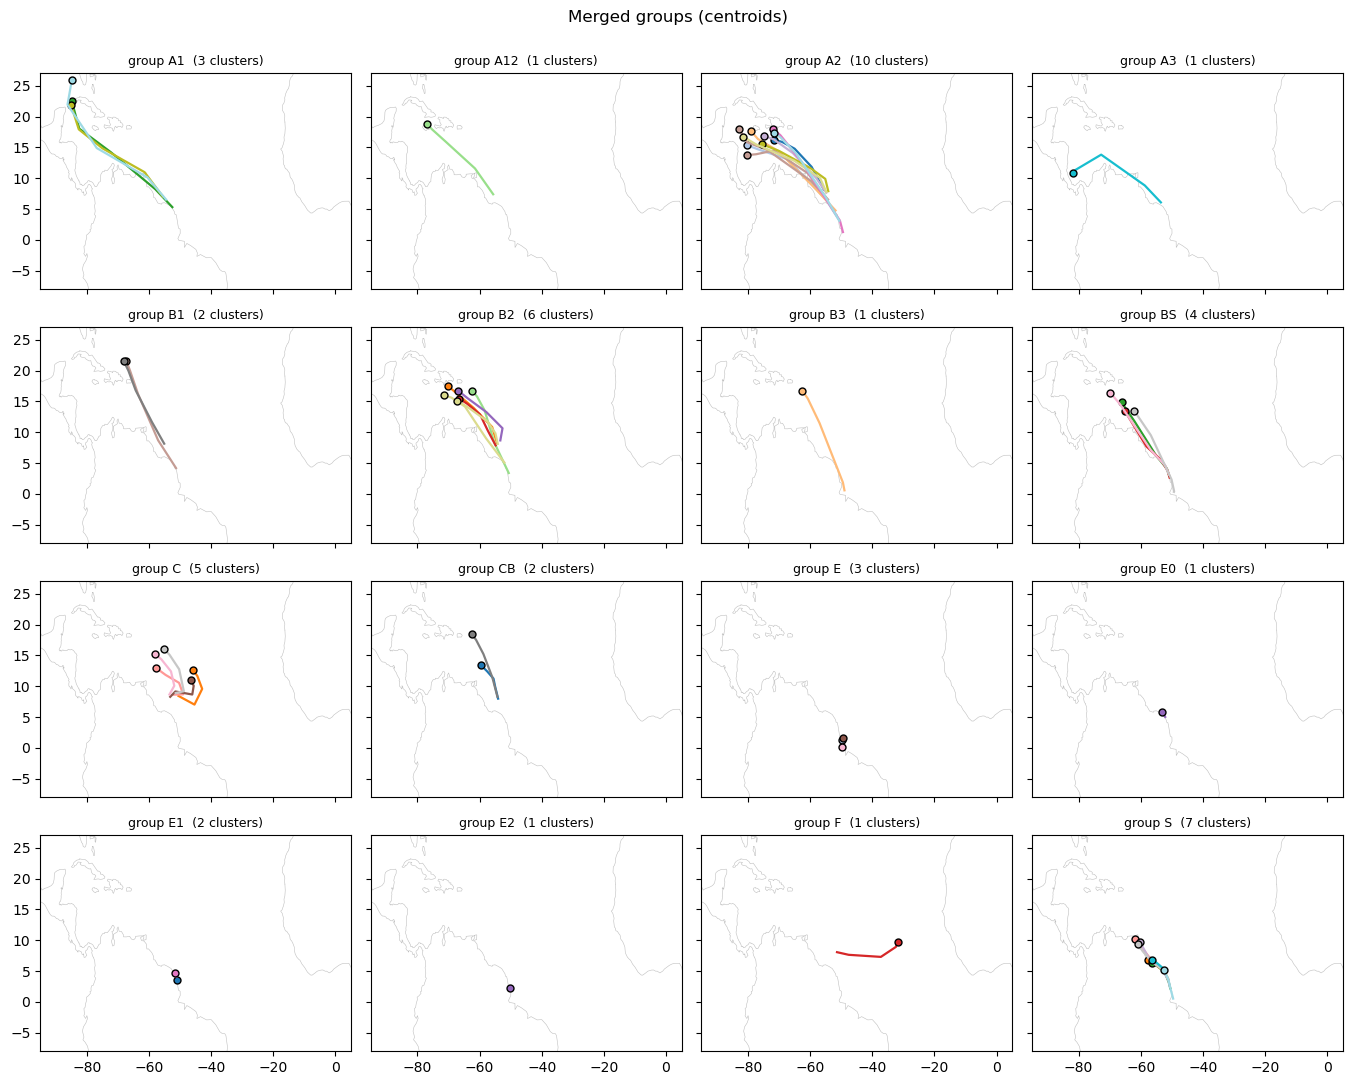

In [21]:
letters = sorted(set(ASSIGN.values()))
NCOLg = min(4, len(letters))
nrowg = int(np.ceil(len(letters) / NCOLg))
cmap  = plt.get_cmap("tab20", K)
fig, axes = plt.subplots(nrowg, NCOLg, figsize=(3.4 * NCOLg, 2.7 * nrowg),
                         squeeze=False, sharex=True, sharey=True)
for i, L in enumerate(letters):
    ax  = axes[i // NCOLg][i % NCOLg]
    draw_coast(ax)
    mem = [c for c in range(K) if ASSIGN[c] == L]
    for c in mem:
        ax.plot(cent_deg[c, 1::2], cent_deg[c, 0::2], "-", color=cmap(c), lw=1.6)
        ax.plot(cent_deg[c, -1], cent_deg[c, -2], "o", color=cmap(c), mec="k", ms=5)
    ax.set_title(f"group {L}  ({len(mem)} clusters)", fontsize=9)
for j in range(len(letters), nrowg * NCOLg):
    axes[j // NCOLg][j % NCOLg].axis("off")
fig.suptitle("Merged groups (centroids)", y=1.0)
fig.tight_layout(); plt.show()

In [22]:
from itertools import combinations
def cdist(a, b):                       # geo distance between two full centroid tracks (deg)
    return float(np.sqrt(((cent_deg[a] - cent_deg[b])**2).sum()))

print("group  n  max_within_dist(deg)  members")
for L in sorted(set(ASSIGN.values())):
    m = [c for c in range(K) if ASSIGN[c] == L]
    spread = max((cdist(a, b) for a, b in combinations(m, 2)), default=0.0)
    flag = "  <-- loose?" if spread > 12 else ""
    print(f"  {L:4s} {len(m):2d}      {spread:6.1f}            {m}{flag}")

print("\nclosest different-label cluster pairs (merge/boundary candidates):")
pairs = sorted((cdist(a, b), a, b) for a, b in combinations(range(K), 2) if ASSIGN[a] != ASSIGN[b])
for d, a, b in pairs[:12]:
    print(f"  {d:5.1f} deg : {a}({ASSIGN[a]})  <->  {b}({ASSIGN[b]})")


group  n  max_within_dist(deg)  members
  A1    3         8.8            [12, 41, 47]
  A12   1         0.0            [14]
  A2   10        22.9            [2, 3, 8, 24, 27, 28, 30, 40, 42, 49]  <-- loose?
  A3    1         0.0            [46]
  B1    2         6.7            [29, 36]
  B2    6        14.4            [7, 13, 15, 21, 43, 44]  <-- loose?
  B3    1         0.0            [9]
  BS    4        17.2            [10, 16, 34, 38]  <-- loose?
  C     5        21.6            [6, 19, 25, 32, 37]  <-- loose?
  CB    2        10.1            [0, 35]
  E     3         3.2            [4, 26, 33]
  E0    1         0.0            [20]
  E1    2         2.7            [1, 31]
  E2    1         0.0            [22]
  F     1         0.0            [17]
  S     7        23.2            [5, 11, 18, 23, 39, 45, 48]  <-- loose?

closest different-label cluster pairs (merge/boundary candidates):
    2.4 deg : 22(E2)  <->  26(E)
    2.9 deg : 4(E)  <->  22(E2)
    3.2 deg : 1(E1)  <->  22(E2)


## Distance of every cluster from the `REF_GROUP` centroids
`REF_GROUP` has one centroid per sampled day; the y axis is those centroid
**locations** (lat, lon), one row each. For each row, the x axis is how far
every other cluster's centroid sits from that `REF_GROUP` centroid, in degrees.
One line per cluster, coloured by broad letter.

Lines start bunched near the release point and spread out downstream: where a
line pulls away marks where that pathway stops following `REF_GROUP`. A line
still low at the last centroid is a merge candidate; a colour sitting inside
another colour's bundle is worth re-checking in `ASSIGN`.


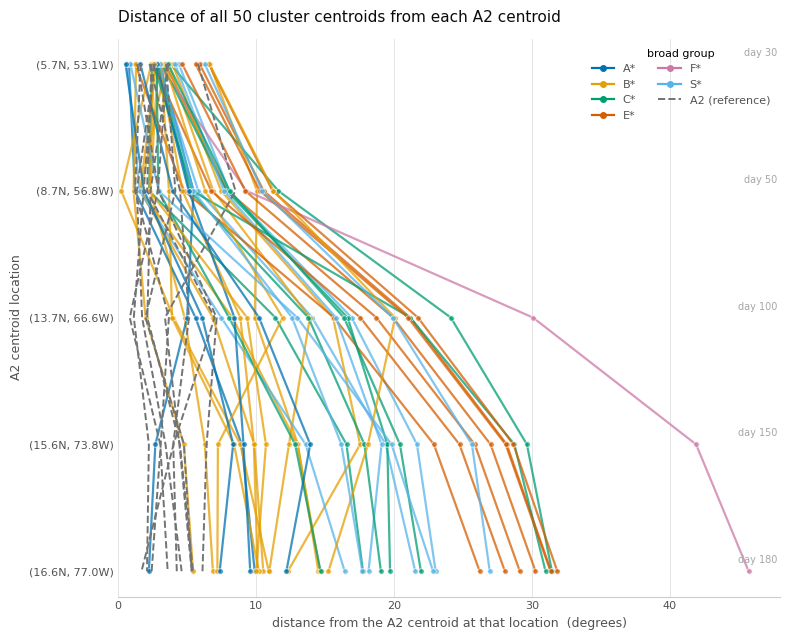

distance from group A2 (clusters [2, 3, 8, 24, 27, 28, 30, 40, 42, 49]) per day, degrees

 clus  grp  d   30  d   50  d  100  d  150  d  180
   40  A2      2.4     2.1     7.0     4.0     1.7
   24  A2      2.6     1.8     1.1     2.2     2.1
   14  A12     3.0     5.5     5.0     2.7     2.2
    8  A2      1.6     1.2     3.7     3.1     2.4
    3  A2      3.5     2.9     0.8     3.0     3.6
   28  A2      2.3     4.5     5.1     4.0     4.2
   42  A2      2.7     1.3     1.7     3.4     4.6
   30  A2      5.8     8.5     3.4     4.4     5.3
    2  A2      3.5     4.1     2.0     4.8     5.3
   49  A2      3.6     2.3     2.1     4.5     5.4
   43  B2      1.3     1.1     2.0     4.8     5.4
   27  A2      1.4     2.9     7.1     6.4     6.1
    7  B2      2.9     2.3     4.8     6.3     6.9
   34  BS      3.4     6.3    11.9     7.2     7.2
   46  A3      0.5     1.9     6.1     8.3     7.4
   41  A1      2.8     5.1     8.4     9.1     9.6
   12  A1      0.8     1.2     5.6     9.0 

In [29]:
REF_GROUP = "A2"          # any letter used in ASSIGN

# cent_deg row layout: [lat_d0, lon_d0, lat_d1, lon_d1, ...] -> (K, n_days, 2)
tracks = cent_deg.reshape(K, len(C.DAYS), 2)
ref_members = [c for c in range(K) if ASSIGN[c] == REF_GROUP]
ref = tracks[ref_members].mean(axis=0)                  # (n_days, 2) mean track

# distance at EACH day, not collapsed over days
dist = np.sqrt(((tracks - ref) ** 2).sum(axis=2))       # (K, n_days) degrees

broad = sorted({ASSIGN[c][0] for c in range(K)})        # A, B, C, E, F, S

PAL = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # green
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
    "#56B4E9",  # sky blue
    "#F0E442",  # yellow
    "#000000",  # black
]

color = {L: PAL[i] for i, L in enumerate(broad)}
INK, MUTED = "#0b0b0b", "#52514e"

# y axis = A1's centroid LOCATION at each day, one evenly-spaced row per point
def coord(la, lo):
    return (f"({abs(la):.1f}{'N' if la >= 0 else 'S'}, "
            f"{abs(lo):.1f}{'W' if lo < 0 else 'E'})")

rows = np.arange(len(C.DAYS))

fig, ax = plt.subplots(figsize=(8, 6.5))
for c in range(K):
    if c in ref_members:
        continue
    ax.plot(dist[c], rows, "-o", color=color[ASSIGN[c][0]], lw=1.6, ms=4,
            alpha=.75, mec="white", mew=.6, zorder=2)
for c in ref_members:                                    # the reference itself
    ax.plot(dist[c], rows, "--", color="0.45", lw=1.4, zorder=3)

ax.set_yticks(rows)
ax.set_yticklabels([coord(la, lo) for la, lo in ref], fontsize=9, color=INK)
ax.invert_yaxis()
ax.set_ylabel(f"{REF_GROUP} centroid location", fontsize=9, color=MUTED)
# day annotated, not used as the scale
for r, d in zip(rows, C.DAYS):
    ax.annotate(f"day {d}", (1.0, r), xycoords=("axes fraction", "data"),
                xytext=(-2, 8), textcoords="offset points",
                ha="right", va="center", fontsize=7, color="0.65")
ax.set_xlabel(f"distance from the {REF_GROUP} centroid at that location  (degrees)",
              fontsize=9, color=MUTED)
ax.set_xlim(left=0)
ax.xaxis.grid(True, color="0.88", lw=.6)
ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color("0.8")
ax.tick_params(colors=MUTED, labelsize=8, length=0)

for L in broad:
    ax.plot([], [], "-o", color=color[L], lw=1.6, ms=4, label=f"{L}*")
ax.plot([], [], "--", color="0.45", lw=1.4, label=f"{REF_GROUP} (reference)")
ax.legend(loc="upper right", frameon=False, fontsize=8, labelcolor=MUTED,
          title="broad group", title_fontsize=8, ncol=2)
ax.set_title(f"Distance of all {K} cluster centroids from each {REF_GROUP} centroid",
             fontsize=11, color=INK, pad=12, loc="left")
fig.tight_layout()
# fig.savefig(f"distance_from_{REF_GROUP}_centroids.pdf", bbox_inches="tight")
plt.show()

hdr = "  ".join(f"d{d:>5}" for d in C.DAYS)
print(f"distance from group {REF_GROUP} (clusters {ref_members}) per day, degrees\n")
print(f" clus  grp  {hdr}")
for c in sorted(range(K), key=lambda c: dist[c, -1]):
    row = "  ".join(f"{v:6.1f}" for v in dist[c])
    print(f" {c:4d}  {ASSIGN[c]:4s} {row}")


In [11]:
D = np.array([[cdist(a, b) for b in range(K)] for a in range(K)]); np.fill_diagonal(D, np.inf)
bad = [(c, D[c].argmin()) for c in range(K) if ASSIGN[c][0] != ASSIGN[int(D[c].argmin())][0]]
print("clusters whose NEAREST neighbor is a different broad letter:")
for c, nn in bad:
    print(f"  {c}({ASSIGN[c]}) -> {nn}({ASSIGN[nn]}) at {D[c,nn]:.1f} deg")
print("none -> broad grouping is clean" if not bad else f"{len(bad)} to check")


clusters whose NEAREST neighbor is a different broad letter:
  0(A2) -> 32(E) at 5.5 deg
  1(E1) -> 31(A1) at 2.7 deg
  3(BS) -> 8(F) at 6.0 deg
  4(E2) -> 26(CB) at 1.0 deg
  5(A2) -> 45(F) at 4.1 deg
  6(C) -> 25(S) at 8.2 deg
  8(F) -> 3(BS) at 6.0 deg
  9(S) -> 10(B2) at 9.2 deg
  10(B2) -> 16(A1) at 6.2 deg
  11(B3) -> 5(A2) at 4.9 deg
  12(C) -> 41(S) at 6.4 deg
  13(B2) -> 35(A12) at 7.5 deg
  15(S) -> 44(C) at 3.8 deg
  16(A1) -> 10(B2) at 6.2 deg
  17(BS) -> 6(C) at 20.0 deg
  18(E) -> 39(A2) at 8.0 deg
  21(E0) -> 44(C) at 3.9 deg
  22(A2) -> 26(CB) at 2.4 deg
  23(B2) -> 5(A2) at 4.8 deg
  25(S) -> 6(C) at 8.2 deg
  26(CB) -> 4(E2) at 1.0 deg
  27(E2) -> 41(S) at 6.1 deg
  29(B2) -> 36(A2) at 6.7 deg
  30(C) -> 49(E1) at 6.8 deg
  31(A1) -> 1(E1) at 2.7 deg
  32(E) -> 0(A2) at 5.5 deg
  33(A3) -> 4(E2) at 2.2 deg
  35(A12) -> 21(E0) at 7.2 deg
  36(A2) -> 29(B2) at 6.7 deg
  38(B2) -> 16(A1) at 7.6 deg
  39(A2) -> 23(B2) at 5.1 deg
  41(S) -> 27(E2) at 6.1 deg
  42(A2) -> 8(

In [12]:
fine_names  = sorted(set(ASSIGN.values()))               # 17 labels
fine_id     = {L: i for i, L in enumerate(fine_names)}
GROUP_MAP   = {c: fine_id[ASSIGN[c]] for c in range(K)}   # cluster id -> group id
GROUP_NAMES = {i: L for L, i in fine_id.items()}          # group id  -> "A2", "B1", ...
# broad letter downstream:  broad = GROUP_NAMES[g][0]     # "A2" -> "A"

print("GROUP_MAP =", GROUP_MAP)
print("GROUP_NAMES =", GROUP_NAMES)


GROUP_MAP = {0: 2, 1: 12, 2: 4, 3: 7, 4: 13, 5: 2, 6: 8, 7: 5, 8: 14, 9: 15, 10: 5, 11: 6, 12: 8, 13: 5, 14: 14, 15: 15, 16: 0, 17: 7, 18: 10, 19: 15, 20: 2, 21: 11, 22: 2, 23: 5, 24: 6, 25: 15, 26: 9, 27: 13, 28: 5, 29: 5, 30: 8, 31: 0, 32: 10, 33: 3, 34: 5, 35: 1, 36: 2, 37: 15, 38: 5, 39: 2, 40: 4, 41: 15, 42: 2, 43: 7, 44: 8, 45: 14, 46: 5, 47: 9, 48: 4, 49: 12}
GROUP_NAMES = {0: 'A1', 1: 'A12', 2: 'A2', 3: 'A3', 4: 'B1', 5: 'B2', 6: 'B3', 7: 'BS', 8: 'C', 9: 'CB', 10: 'E', 11: 'E0', 12: 'E1', 13: 'E2', 14: 'F', 15: 'S'}


## Export -> paste into `config.py`

In [13]:
name2id     = {L: i for i, L in enumerate(letters)}
GROUP_MAP   = {c: name2id[ASSIGN[c]] for c in range(K)}
GROUP_NAMES = {i: L for L, i in name2id.items()}

print("# weights used:", _wd)
print("GROUP_MAP =", GROUP_MAP)
print("GROUP_NAMES =", GROUP_NAMES)
print()
for L in letters:
    print(f"  {L}: {[c for c in range(K) if ASSIGN[c] == L]}")

# weights used: {30: 0.5, 50: 1.5, 100: 1.0, 150: 1.5, 180: 2.0}
GROUP_MAP = {0: 2, 1: 12, 2: 4, 3: 7, 4: 13, 5: 2, 6: 8, 7: 5, 8: 14, 9: 15, 10: 5, 11: 6, 12: 8, 13: 5, 14: 14, 15: 15, 16: 0, 17: 7, 18: 10, 19: 15, 20: 2, 21: 11, 22: 2, 23: 5, 24: 6, 25: 15, 26: 9, 27: 13, 28: 5, 29: 5, 30: 8, 31: 0, 32: 10, 33: 3, 34: 5, 35: 1, 36: 2, 37: 15, 38: 5, 39: 2, 40: 4, 41: 15, 42: 2, 43: 7, 44: 8, 45: 14, 46: 5, 47: 9, 48: 4, 49: 12}
GROUP_NAMES = {0: 'A1', 1: 'A12', 2: 'A2', 3: 'A3', 4: 'B1', 5: 'B2', 6: 'B3', 7: 'BS', 8: 'C', 9: 'CB', 10: 'E', 11: 'E0', 12: 'E1', 13: 'E2', 14: 'F', 15: 'S'}

  A1: [16, 31]
  A12: [35]
  A2: [0, 5, 20, 22, 36, 39, 42]
  A3: [33]
  B1: [2, 40, 48]
  B2: [7, 10, 13, 23, 28, 29, 34, 38, 46]
  B3: [11, 24]
  BS: [3, 17, 43]
  C: [6, 12, 30, 44]
  CB: [26, 47]
  E: [18, 32]
  E0: [21]
  E1: [1, 49]
  E2: [4, 27]
  F: [8, 14, 45]
  S: [9, 15, 19, 25, 37, 41]


## Hierarchical clustering of the centroids
The same centroid-to-centroid distance used above for `REF_GROUP`, but computed
for **every pair** instead of against one reference, then fed to an
agglomerative tree. This is the automatic counterpart to the hand grouping in
`ASSIGN`: the dendrogram proposes a hierarchy, and the crosstab below shows
where it agrees with your letters and where it disagrees.

Read it as a second opinion, not a verdict - k=50 over-resolves on purpose, and
the tree has no idea which splits are physically meaningful.


In [ ]:
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet
from sklearn.metrics import adjusted_rand_score

# --- TUNE ME -----------------------------------------------------------------
LINKAGE   = "average"   # ward | average | complete | single | centroid
N_GROUPS  = len(set(ASSIGN.values()))   # cut the tree into this many groups
# -----------------------------------------------------------------------------

# THE DISTANCE MATRIX -----------------------------------------------------------
# Exactly the metric the REF_GROUP cell and cell 16 use, applied to every pair
# instead of to one reference. Each centroid is a full track flattened to
#   [lat_d0, lon_d0, lat_d1, lon_d1, ... ]   (2 x len(DAYS) = 10 numbers)
# and the distance between two clusters is the plain Euclidean norm of their
# difference in that space - i.e. the root-sum-square of the per-day separations
# in degrees. pdist returns it CONDENSED (K*(K-1)/2 = 1225 pairs, no diagonal),
# which is the form scipy's linkage() wants.
#
# Note this lives in DEGREE space (unweighted, unstandardized), like the rest of
# the diagnostics in this notebook - not the standardized+weighted space k-means
# actually optimised in. Set SPACE="fit" to use that one instead.
SPACE = "degrees"
X = cent_deg if SPACE == "degrees" else (km.cluster_centers_)

Dvec = pdist(X, metric="euclidean")          # condensed distance matrix
Dmat = squareform(Dvec)                      # square form, for the heatmap
print(f"distance matrix: {Dmat.shape}, {len(Dvec)} unique pairs | space: {SPACE}")
print(f"  min {Dvec.min():.1f}  median {np.median(Dvec):.1f}  max {Dvec.max():.1f} deg")

# Which linkage? The cophenetic correlation says how faithfully the tree
# reproduces the distance matrix it was built from. `centroid` and `median` can
# score well but are non-monotonic (the dendrogram can show inversions), so
# `average` (UPGMA) is the default here: best of the monotonic methods.
print(f"\n{'method':10s} {'cophenetic':>10s}")
for _m in ("ward", "average", "complete", "single", "centroid"):
    print(f"{_m:10s} {cophenet(linkage(Dvec, method=_m), Dvec)[0]:10.3f}")

Z = linkage(Dvec, method=LINKAGE)
coph, _ = cophenet(Z, Dvec)
print(f"\nusing {LINKAGE} | cophenetic correlation {coph:.3f}"
      "   (1.0 = tree reproduces the distances exactly)")

# --- dendrogram, leaves labelled with the manual letter ----------------------
labels = [f"{c}  {ASSIGN[c]}" for c in range(K)]
fig, ax = plt.subplots(figsize=(8, 11))
dd = dendrogram(Z, labels=labels, orientation="left", ax=ax,
                color_threshold=Z[-(N_GROUPS - 1), 2],
                above_threshold_color="0.75", leaf_font_size=8)
ax.axvline(Z[-(N_GROUPS - 1), 2], color="0.4", lw=.8, ls="--")
ax.set_xlabel("merge distance (deg)", fontsize=9)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.tick_params(length=0, labelsize=8)
ax.set_title(f"Hierarchical clustering of the {K} centroids "
             f"({LINKAGE} linkage, cut at {N_GROUPS} groups)",
             fontsize=11, pad=12, loc="left")
fig.tight_layout()
fig.savefig(f"dendrogram_{LINKAGE}_{N_GROUPS}.pdf", bbox_inches="tight")
plt.show()

# --- how well does the tree agree with the manual grouping? ------------------
auto = fcluster(Z, t=N_GROUPS, criterion="maxclust")
manual = np.array([ASSIGN[c] for c in range(K)])
ari = adjusted_rand_score(manual, auto)
print(f"\nadjusted Rand index vs the manual ASSIGN: {ari:.3f}"
      "   (1 = identical partition, 0 = chance)")

ct = pd.crosstab(pd.Series(manual, name="manual"),
                 pd.Series(auto, name="auto branch"))
print("\nmanual letter x automatic branch:")
print(ct.to_string())

split = ct[(ct > 0).sum(axis=1) > 1]
if len(split):
    print(f"\nmanual groups the tree SPLITS across branches: {list(split.index)}")
merged = ct.loc[:, (ct > 0).sum(axis=0) > 1]
if merged.shape[1]:
    print(f"branches that MERGE several manual letters: {list(merged.columns)}")
    for b in merged.columns:
        who = ct.index[ct[b] > 0].tolist()
        print(f"  branch {b}: {who}")

# --- ordered distance heatmap ------------------------------------------------
order = dd["leaves"][::-1]                    # dendrogram order, top to bottom
fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(Dmat[np.ix_(order, order)], cmap="magma_r")
ax.set_xticks(range(K)); ax.set_yticks(range(K))
ax.set_xticklabels([f"{c}" for c in order], fontsize=6, rotation=90)
ax.set_yticklabels([f"{c} {ASSIGN[c]}" for c in order], fontsize=6)
cb = fig.colorbar(im, ax=ax, fraction=.04, pad=.02)
cb.set_label("centroid distance (deg)", fontsize=9)
ax.set_title("Distance matrix, rows/cols in dendrogram order",
             fontsize=11, pad=10, loc="left")
fig.tight_layout()
plt.show()


## ... and the same thing on the LAST POSITION only
Identical technique to the cell above - condensed pairwise Euclidean distance
(`pdist`) then agglomerative linkage - but the observation vector shrinks from
the whole track to just the day-180 endpoint:

    [lat_30, lon_30, ... , lat_180, lon_180]   ->   [lat_180, lon_180]

so cluster-to-cluster distance becomes simply *how far apart the two endpoints
are*. Everything about the route is discarded: two clusters that arrive at the
same place by opposite paths are now indistinguishable.

The second figure puts the automatic branches and your manual letters side by
side on the endpoints themselves, which is the quickest way to see whether a
group is a destination or a pathway.


endpoint distance matrix: 1225 pairs | min 0.1  median 14.3  max 55.4 deg
(full-track version above: median 24.4  max 89.1 deg)

method     cophenetic
ward            0.674
average         0.703
complete        0.683
single          0.503
centroid        0.736

using average | cophenetic correlation 0.703

adjusted Rand index vs manual ASSIGN : 0.332
adjusted Rand index vs the FULL-track tree: 0.456   (how much the endpoint changes the answer)


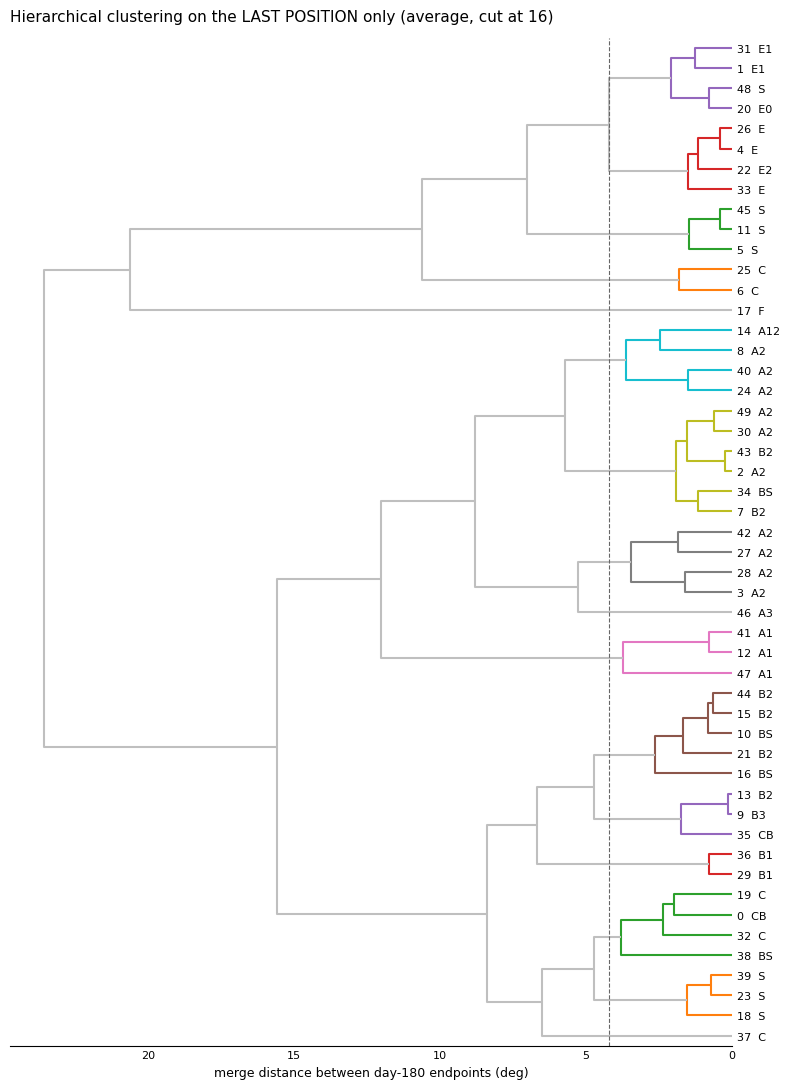

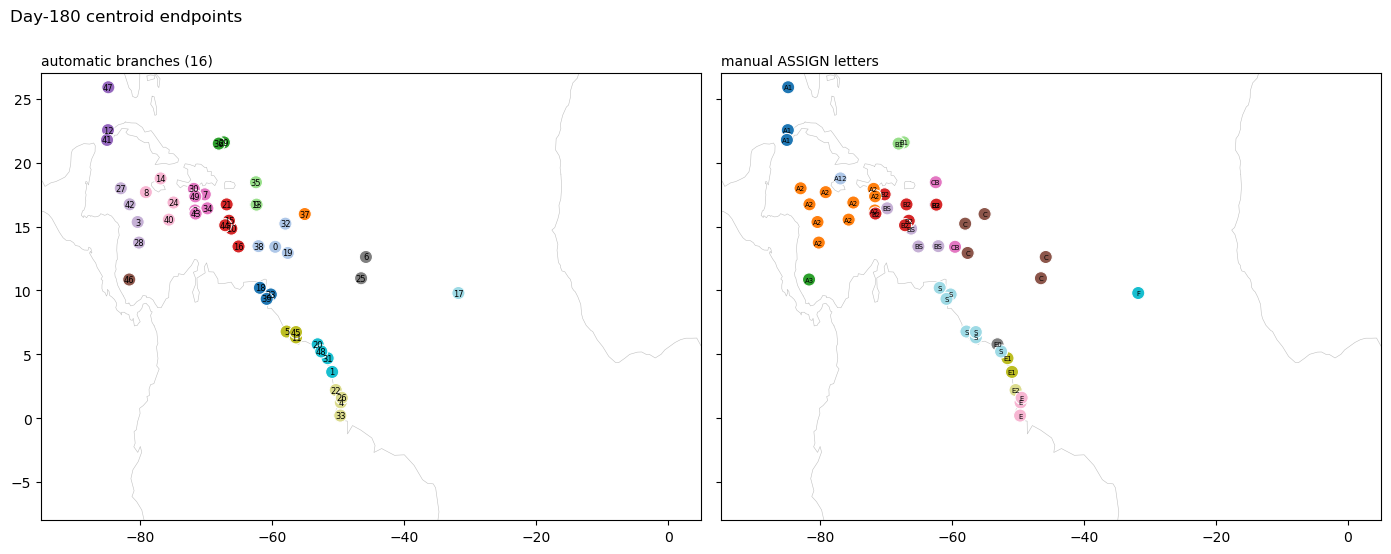

manual letter x endpoint branch:
endpoint branch  1   2   3   4   5   6   7   8   9   10  11  12  13  14  15  16
manual                                                                         
A1                0   0   0   0   0   0   3   0   0   0   0   0   0   0   0   0
A12               0   0   0   0   0   0   0   0   0   0   1   0   0   0   0   0
A2                0   0   0   0   0   0   0   4   0   3   3   0   0   0   0   0
A3                0   0   0   0   0   0   0   0   1   0   0   0   0   0   0   0
B1                0   0   0   2   0   0   0   0   0   0   0   0   0   0   0   0
B2                0   0   0   0   1   3   0   0   0   2   0   0   0   0   0   0
B3                0   0   0   0   1   0   0   0   0   0   0   0   0   0   0   0
BS                0   1   0   0   0   2   0   0   0   1   0   0   0   0   0   0
C                 0   2   1   0   0   0   0   0   0   0   0   2   0   0   0   0
CB                0   1   0   0   1   0   0   0   0   0   0   0   0   0   0   0
E      

In [33]:
# --- TUNE ME -----------------------------------------------------------------
LINKAGE_END = "average"
N_GROUPS_END = len(set(ASSIGN.values()))
# -----------------------------------------------------------------------------

# SAME technique as the cell above - condensed pairwise Euclidean distance via
# pdist, then agglomerative linkage - but the observation vector is now just the
# LAST position instead of the whole track:
#     [lat_180, lon_180]      (2 numbers)   instead of   [lat_30, lon_30, ...]
# So the distance between two clusters is simply how far apart their day-180
# endpoints are, in degrees. Everything about where they travelled to get there
# is discarded: two clusters that reach the same place by opposite routes are
# now identical.
end = cent_deg[:, -2:][:, ::-1]          # -> columns (lat, lon) -> keep as (lat, lon)
end_lat, end_lon = cent_deg[:, -2], cent_deg[:, -1]
Xend = np.column_stack([end_lat, end_lon])

Dend = pdist(Xend, metric="euclidean")
print(f"endpoint distance matrix: {len(Dend)} pairs | "
      f"min {Dend.min():.1f}  median {np.median(Dend):.1f}  max {Dend.max():.1f} deg")
print(f"(full-track version above: median {np.median(Dvec):.1f}  max {Dvec.max():.1f} deg)")

print(f"\n{'method':10s} {'cophenetic':>10s}")
for _m in ("ward", "average", "complete", "single", "centroid"):
    print(f"{_m:10s} {cophenet(linkage(Dend, method=_m), Dend)[0]:10.3f}")

Zend = linkage(Dend, method=LINKAGE_END)
coph_end, _ = cophenet(Zend, Dend)
print(f"\nusing {LINKAGE_END} | cophenetic correlation {coph_end:.3f}")

auto_end = fcluster(Zend, t=N_GROUPS_END, criterion="maxclust")
manual = np.array([ASSIGN[c] for c in range(K)])
print(f"\nadjusted Rand index vs manual ASSIGN : {adjusted_rand_score(manual, auto_end):.3f}")
print(f"adjusted Rand index vs the FULL-track tree: "
      f"{adjusted_rand_score(auto, auto_end):.3f}"
      "   (how much the endpoint changes the answer)")

# --- dendrogram --------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 11))
dd_end = dendrogram(Zend, labels=[f"{c}  {ASSIGN[c]}" for c in range(K)],
                    orientation="left", ax=ax,
                    color_threshold=Zend[-(N_GROUPS_END - 1), 2],
                    above_threshold_color="0.75", leaf_font_size=8)
ax.axvline(Zend[-(N_GROUPS_END - 1), 2], color="0.4", lw=.8, ls="--")
ax.set_xlabel("merge distance between day-%d endpoints (deg)" % C.DAYS[-1], fontsize=9)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.tick_params(length=0, labelsize=8)
ax.set_title(f"Hierarchical clustering on the LAST POSITION only "
             f"({LINKAGE_END}, cut at {N_GROUPS_END})",
             fontsize=11, pad=12, loc="left")
fig.tight_layout()
fig.savefig(f"dendrogram_endpoint_{LINKAGE_END}_{N_GROUPS_END}.pdf", bbox_inches="tight")
plt.show()

# --- the endpoints themselves, coloured by the branch they landed in ---------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True, sharey=True)
cmap = plt.get_cmap("tab20", N_GROUPS_END)
for ax, colour_by, ttl in (
        (axes[0], auto_end, f"automatic branches ({N_GROUPS_END})"),
        (axes[1], None, "manual ASSIGN letters")):
    draw_coast(ax)
    if colour_by is not None:
        ax.scatter(end_lon, end_lat, c=[cmap(b - 1) for b in colour_by],
                   s=90, ec="white", linewidths=.8, zorder=3)
        for c in range(K):
            ax.annotate(str(c), (end_lon[c], end_lat[c]), fontsize=6,
                        ha="center", va="center", zorder=4)
    else:
        letters = sorted(set(manual))
        lc = {L: plt.get_cmap("tab20", len(letters))(i) for i, L in enumerate(letters)}
        ax.scatter(end_lon, end_lat, c=[lc[ASSIGN[c]] for c in range(K)],
                   s=90, ec="white", linewidths=.8, zorder=3)
        for c in range(K):
            ax.annotate(ASSIGN[c], (end_lon[c], end_lat[c]), fontsize=5,
                        ha="center", va="center", zorder=4)
    ax.set_title(ttl, fontsize=10, loc="left")
fig.suptitle(f"Day-{C.DAYS[-1]} centroid endpoints", y=1.0, x=.01, ha="left")
fig.tight_layout(); plt.show()

ct_end = pd.crosstab(pd.Series(manual, name="manual"),
                     pd.Series(auto_end, name="endpoint branch"))
print("manual letter x endpoint branch:")
print(ct_end.to_string())
split_end = ct_end[(ct_end > 0).sum(axis=1) > 1]
if len(split_end):
    print(f"\nmanual groups split by the endpoint tree: {list(split_end.index)}")
for b in ct_end.columns:
    who = ct_end.index[ct_end[b] > 0].tolist()
    if len(who) > 1:
        print(f"  branch {b} merges: {who}")


## ... and with the days weighted
The two trees above treat every sampled day as equally important. The k-means
fit does not - it uses `DAY_WEIGHTS`, so day 180 pulls 4x harder than day 30 and
the retroflection window (50/150) 3x. This applies the same weighting to the
distance matrix, so the tree is built in a space consistent with the fit rather
than in plain degrees.

Each day's two columns are scaled by `sqrt(w_d)`, exactly as cell 1 builds `W`,
which puts a factor `w_d` on that day's contribution to the SQUARED distance:

    d2 = sum_d  w_d * [ (dlat_d)^2 + (dlon_d)^2 ]

`STANDARDIZE = True` goes one step further and reproduces the exact space
k-means optimised in (z-scored, then weighted); `False` keeps interpretable
degrees.


day weights: {30: 0.5, 50: 1.5, 100: 1.0, 150: 1.5, 180: 2.0}
column multipliers (sqrt): [0.707 0.707 1.225 1.225 1.    1.    1.225 1.225 1.414 1.414]

weighted distance matrix: 1225 pairs | min 1.1  median 30.0  max 112.4 (weighted deg)
unweighted, for comparison: median 24.4  max 89.1 deg

method     cophenetic
ward            0.665
average         0.727
complete        0.674
single          0.516
centroid        0.726

using average | cophenetic correlation 0.727

adjusted Rand index vs manual ASSIGN   : 0.385
                    vs UNWEIGHTED tree  : 0.976
                    vs ENDPOINT tree    : 0.449

nearest-neighbour unchanged by weighting: 40/50 clusters


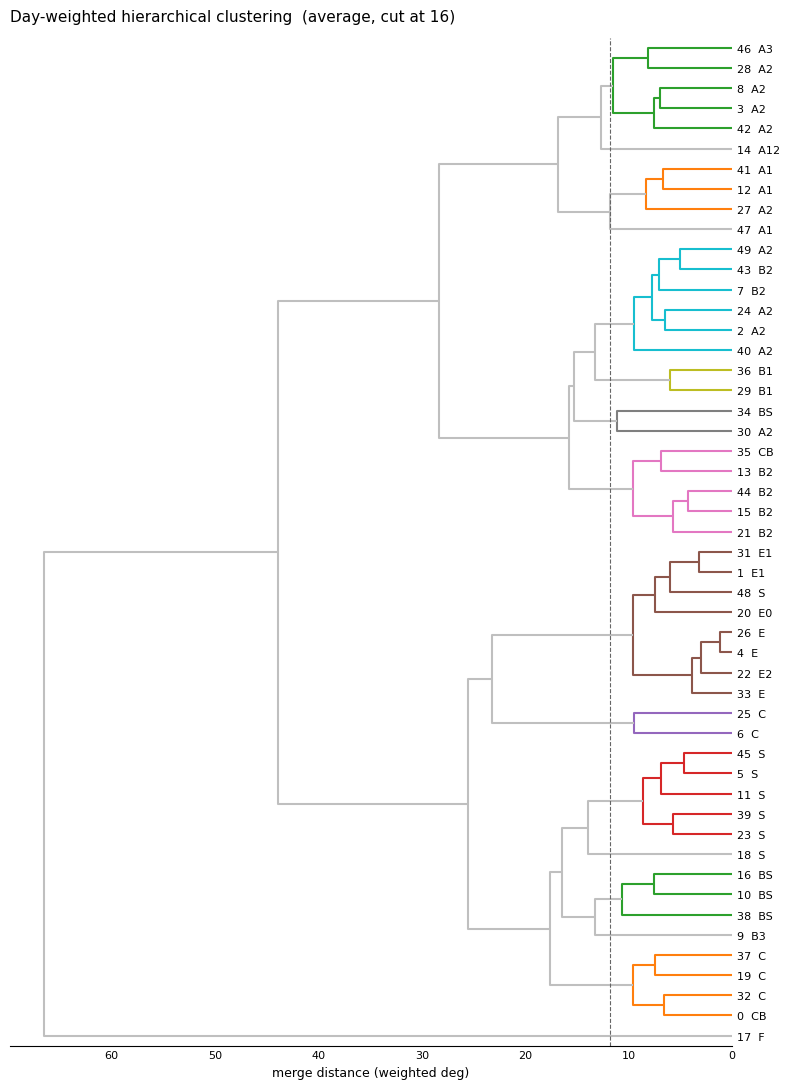

manual letter x day-weighted branch:
weighted branch  1   2   3   4   5   6   7   8   9   10  11  12  13  14  15  16
manual                                                                         
A1                0   0   0   0   0   0   0   0   0   0   0   2   1   0   0   0
A12               0   0   0   0   0   0   0   0   0   0   0   0   0   0   1   0
A2                0   0   0   0   0   0   0   0   1   0   4   1   0   4   0   0
A3                0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   0
B1                0   0   0   0   0   0   0   0   0   2   0   0   0   0   0   0
B2                0   0   0   0   0   0   0   4   0   0   2   0   0   0   0   0
B3                0   0   1   0   0   0   0   0   0   0   0   0   0   0   0   0
BS                0   3   0   0   0   0   0   0   1   0   0   0   0   0   0   0
C                 3   0   0   0   0   2   0   0   0   0   0   0   0   0   0   0
CB                1   0   0   0   0   0   0   1   0   0   0   0   0   0   0   0
E  

In [34]:
# --- TUNE ME -----------------------------------------------------------------
LINKAGE_W = "average"
N_GROUPS_W = len(set(ASSIGN.values()))
STANDARDIZE = False    # False: weighted degrees (interpretable)
                       # True : the exact space k-means optimised in
# -----------------------------------------------------------------------------

# Same pdist -> linkage technique, but the days no longer count equally. Each
# day's two columns are multiplied by sqrt(w_d), exactly as cell 1 builds W for
# the fit, so the squared distance picks up a factor w_d per day:
#
#     d2 = sum_d  w_d * [ (dlat_d)^2 + (dlon_d)^2 ]
#
# With DAY_WEIGHTS = {30: 0.5, 50: 1.5, 100: 1.0, 150: 1.5, 180: 2.0} the day-180
# endpoint carries 4x the pull of day 30, and the retroflection window (50/150)
# 3x. sqrt() is used rather than the raw weight because the weight is meant to
# act on the SQUARED distance - the same convention as the k-means fit.
Wcol = np.array([np.sqrt(_wd[d]) for d in C.DAYS for _ in range(2)])
print("day weights:", _wd)
print("column multipliers (sqrt):", np.round(Wcol, 3))

if STANDARDIZE:
    Xw = (cent_deg - cent_deg.mean(0)) / cent_deg.std(0) * Wcol
    unit = "standardized"
else:
    Xw = cent_deg * Wcol
    unit = "weighted deg"

Dw = pdist(Xw, metric="euclidean")
print(f"\nweighted distance matrix: {len(Dw)} pairs | "
      f"min {Dw.min():.1f}  median {np.median(Dw):.1f}  max {Dw.max():.1f} ({unit})")
print(f"unweighted, for comparison: median {np.median(Dvec):.1f}  max {Dvec.max():.1f} deg")

print(f"\n{'method':10s} {'cophenetic':>10s}")
for _m in ("ward", "average", "complete", "single", "centroid"):
    print(f"{_m:10s} {cophenet(linkage(Dw, method=_m), Dw)[0]:10.3f}")

Zw = linkage(Dw, method=LINKAGE_W)
print(f"\nusing {LINKAGE_W} | cophenetic correlation {cophenet(Zw, Dw)[0]:.3f}")

auto_w = fcluster(Zw, t=N_GROUPS_W, criterion="maxclust")
manual = np.array([ASSIGN[c] for c in range(K)])
print(f"\nadjusted Rand index vs manual ASSIGN   : {adjusted_rand_score(manual, auto_w):.3f}")
print(f"                    vs UNWEIGHTED tree  : {adjusted_rand_score(auto, auto_w):.3f}")
print(f"                    vs ENDPOINT tree    : {adjusted_rand_score(auto_end, auto_w):.3f}")

# how far each cluster's rank-order of neighbours moved when weights came in
same = sum(1 for c in range(K)
           if np.argsort(squareform(Dvec)[c])[1] == np.argsort(squareform(Dw)[c])[1])
print(f"\nnearest-neighbour unchanged by weighting: {same}/{K} clusters")

fig, ax = plt.subplots(figsize=(8, 11))
dd_w = dendrogram(Zw, labels=[f"{c}  {ASSIGN[c]}" for c in range(K)],
                  orientation="left", ax=ax,
                  color_threshold=Zw[-(N_GROUPS_W - 1), 2],
                  above_threshold_color="0.75", leaf_font_size=8)
ax.axvline(Zw[-(N_GROUPS_W - 1), 2], color="0.4", lw=.8, ls="--")
ax.set_xlabel(f"merge distance ({unit})", fontsize=9)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.tick_params(length=0, labelsize=8)
ax.set_title(f"Day-weighted hierarchical clustering  ({LINKAGE_W}, cut at "
             f"{N_GROUPS_W})", fontsize=11, pad=12, loc="left")
fig.tight_layout()
fig.savefig(f"dendrogram_dayweighted_{LINKAGE_W}_{N_GROUPS_W}.pdf", bbox_inches="tight")
plt.show()

ct_w = pd.crosstab(pd.Series(manual, name="manual"),
                   pd.Series(auto_w, name="weighted branch"))
print("manual letter x day-weighted branch:")
print(ct_w.to_string())
for b in ct_w.columns:
    who = ct_w.index[ct_w[b] > 0].tolist()
    if len(who) > 1:
        print(f"  branch {b} merges: {who}")

# NOTE: day weights cannot change the ENDPOINT-only tree. Weighting a single day
# multiplies every pairwise distance by the same constant sqrt(w_180), which
# rescales the dendrogram heights but leaves the merge order - and therefore the
# grouping - identical. Weighting only does something when several days compete.
De = pdist(np.column_stack([cent_deg[:, -2], cent_deg[:, -1]]) * np.sqrt(_wd[C.DAYS[-1]]))
print(f"\nsanity check - endpoint tree under weighting is unchanged: "
      f"{np.allclose(De / np.sqrt(_wd[C.DAYS[-1]]), Dend)}")


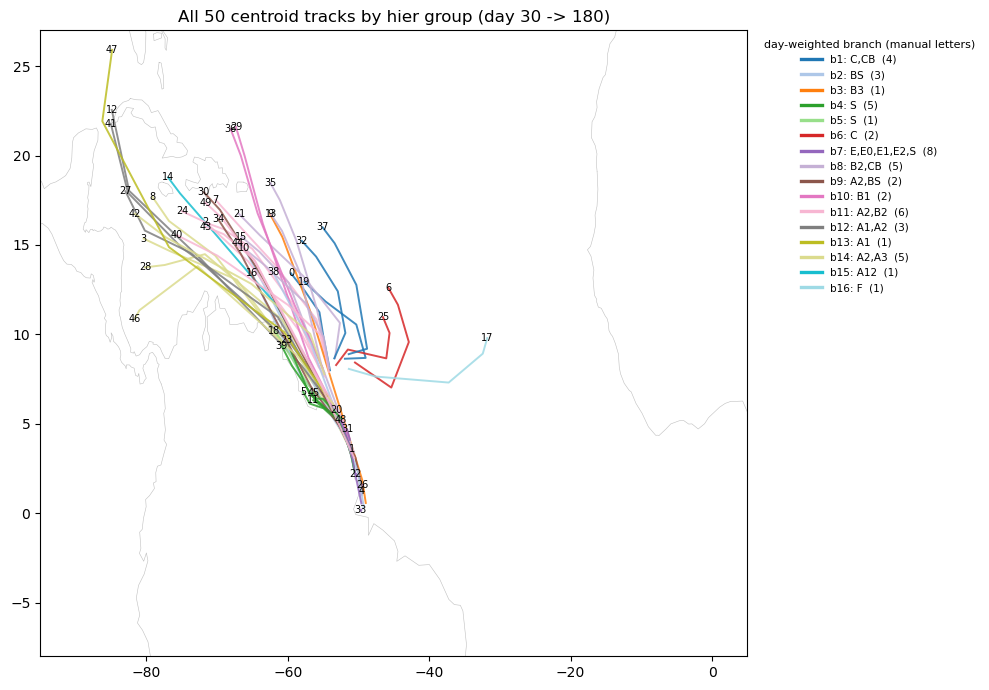

In [37]:
# Centroid tracks coloured by GROUP.
#   "hier"   -> auto_w, the branches from the day-weighted tree (last hier cell)
#   "manual" -> your ASSIGN letters
GROUP_BY = "hier"

if GROUP_BY == "hier":
    gid = {c: int(auto_w[c]) for c in range(K)}
    keys = sorted(set(gid.values()))
    # label each branch with the manual letters it swept up, so the two
    # groupings can be compared straight off the legend
    def _lab(g):
        mem = [c for c in range(K) if gid[c] == g]
        lets = sorted({ASSIGN[c] for c in mem})
        return f"b{g}: {','.join(lets)}  ({len(mem)})"
else:
    gid = {c: ASSIGN[c] for c in range(K)}
    keys = sorted(set(gid.values()))
    def _lab(g):
        return f"{g}  ({sum(1 for c in range(K) if gid[c] == g)})"

gcmap  = plt.get_cmap("tab20", len(keys))
gcolor = {g: gcmap(i) for i, g in enumerate(keys)}

fig, ax = plt.subplots(figsize=(10, 7))
draw_coast(ax)
for c in range(K):
    lo, la = cent_deg[c, 1::2], cent_deg[c, 0::2]      # centroid track (degrees)
    ax.plot(lo, la, "-", color=gcolor[gid[c]], lw=1.4, alpha=.85, zorder=2)
    ax.text(lo[-1], la[-1], str(c), fontsize=7, ha="center", va="center", zorder=4)

handles = [plt.Line2D([], [], color=gcolor[g], lw=2.4, label=_lab(g)) for g in keys]
ax.legend(handles=handles, fontsize=7.5, ncol=1, frameon=False,
          loc="upper left", bbox_to_anchor=(1.01, 1.0),
          title=("day-weighted branch (manual letters)" if GROUP_BY == "hier"
                 else "group (n clusters)"), title_fontsize=8)
ax.set_title(f"All {K} centroid tracks by {GROUP_BY} group "
             f"(day {C.DAYS[0]} -> {C.DAYS[-1]})")
fig.tight_layout(); plt.show()
